# SBERT 설명

### **1. 임베딩(Embedding)의 개념**

정의: 텍스트(단어, 문장)를 고정 길이의 벡터로 변환하는 과정

목적: 기계 학습 알고리즘이 이해할 수 있도록 의미적 정보를 수치로 표현


🧩 예시:
"apple" → [0.12, -0.34, ..., 0.51]

비슷한 단어는 가까운 벡터 위치에 매핑됨

### **2. BERT란?**

명칭: Bidirectional Encoder Representations from Transformers

출시: Google, 2018

핵심 특징:

* 양방향 문맥 이해: 왼쪽-오른쪽 동시에 고려

* 문장 수준의 의미 파악에 강함

### **3. 문장 임베딩(Sentence Embedding) 개념**

정의: (단어가 아니라) 전체 문장을 하나의 벡터로 표현하는 기술

필요성:

* 문서 간 유사도 계산

* 문장 클러스터링

* 토픽 모델링

### 4. SBERT (Sentence-BERT)
제안자: Reimers & Gurevych (2019)

목적: BERT를 문장 임베딩에 최적화

핵심 아이디어:

* 문장 쌍 간 유사도 학습

* 임베딩 벡터 간의 Cosine Similarity가 의미 있는 값을 가짐

📊 장점:

* 문장 간 의미 유사도 정밀 측정 가능

* 클러스터링, 분류, 검색 등에 효과적

### 5. SBERT 기반 토픽 모델링(BERTopic) vs LDA 토픽 모델링

| 항목           | LDA (DTM 기반)        | SBERT 기반                 |
| ------------ | ------------------- | ------------------------ |
| **입력 단위**    | 단어                  | 문장 or 문단                 |
| **토픽 생성 방식** | 단어-문서 행렬 → 확률 기반 추정 | 임베딩 벡터 → 의미적 거리 기반 군집    |
| **의미 해석**    | 단어 빈도 기반 (확률적)      | 의미 유사성 기반 (분포적)          |
| **맥락 고려**    | X (BoW)             | O (문맥 포함)

### ✅ 핵심

* BERT는 문맥을 이해하는 능력이 뛰어나지만, 문장을 하나의 벡터로 잘 표현하진 못함
* SBERT는 문장 간 유사도 학습을 통해 문장을 임베딩할 수 있도록 설계됨
* SBERT를 기반으로 BERTopic이 토픽 모델링에 자주 활용됨

# BERTopic 설명과 기능


In [1]:
# 2분 정도 소요
!pip install bertopic[visualization]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 887.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

### **📌 BERTopic 알고리즘 세 단계**

1️⃣ 문장 임베딩 단계

텍스트 데이터를 SBERT(Sentence-BERT)로 임베딩

문장 간 의미 유사성을 반영한 벡터 생성

기본 사용 모델:

* "paraphrase-MiniLM-L6-v2" (영어)

* "paraphrase-multilingual-MiniLM-L12-v2" (다국어)

2️⃣ 문서 군집화 단계

UMAP: 임베딩 차원 축소

HDBSCAN: 밀도 기반 클러스터링

* 결과: 의미적으로 유사한 문서들을 하나의 클러스터(토픽)로 그룹화

3️⃣ 토픽 표현 생성 단계

각 클러스터 내 문서들을 기반으로
클래스 기반 TF-IDF(c-TF-IDF) 계산

해당 토픽을 가장 잘 설명하는 키워드 추출

| 항목            | 일반 TF-IDF                 | 클래스 기반 TF-IDF (c-TF-IDF)               |
| ------------- | ------------------------- | -------------------------------------- |
| **목적**        | 개별 문서에서 중요한 단어 추출         | 각 **클래스(토픽)** 를 대표하는 단어 추출             |
| **TF 계산 기준**  | 하나의 문서 내 단어 빈도            | 하나의 **클래스(토픽)** 를 하나의 긴 문서처럼 처리해 빈도 계산 |
| **IDF 계산 기준** | 전체 문서 수 중 해당 단어가 포함된 문서 수 | 전체 클래스 수 중 해당 단어가 포함된 클래스 수            |



## 1. 파일 다운로드
1. 학교 학술정보관 로그인: https://lib.skku.edu/#/
2. 자료 탭>Database 탭 이동
3. Web of Science 이동
4. 키워드 검색
5.  Export 토글 클릭 후, Content 토글에서 abstract 포함해서 Excel로 내보내기

`샘플 파일`

: 'LLM'(Large Language Model)을 포함한 2025년 논문

https://github.com/WooYoungSeok/Topic_Modeling_Practice/blob/main/LLM_WfS_0717.xls


- 다운로드 방법
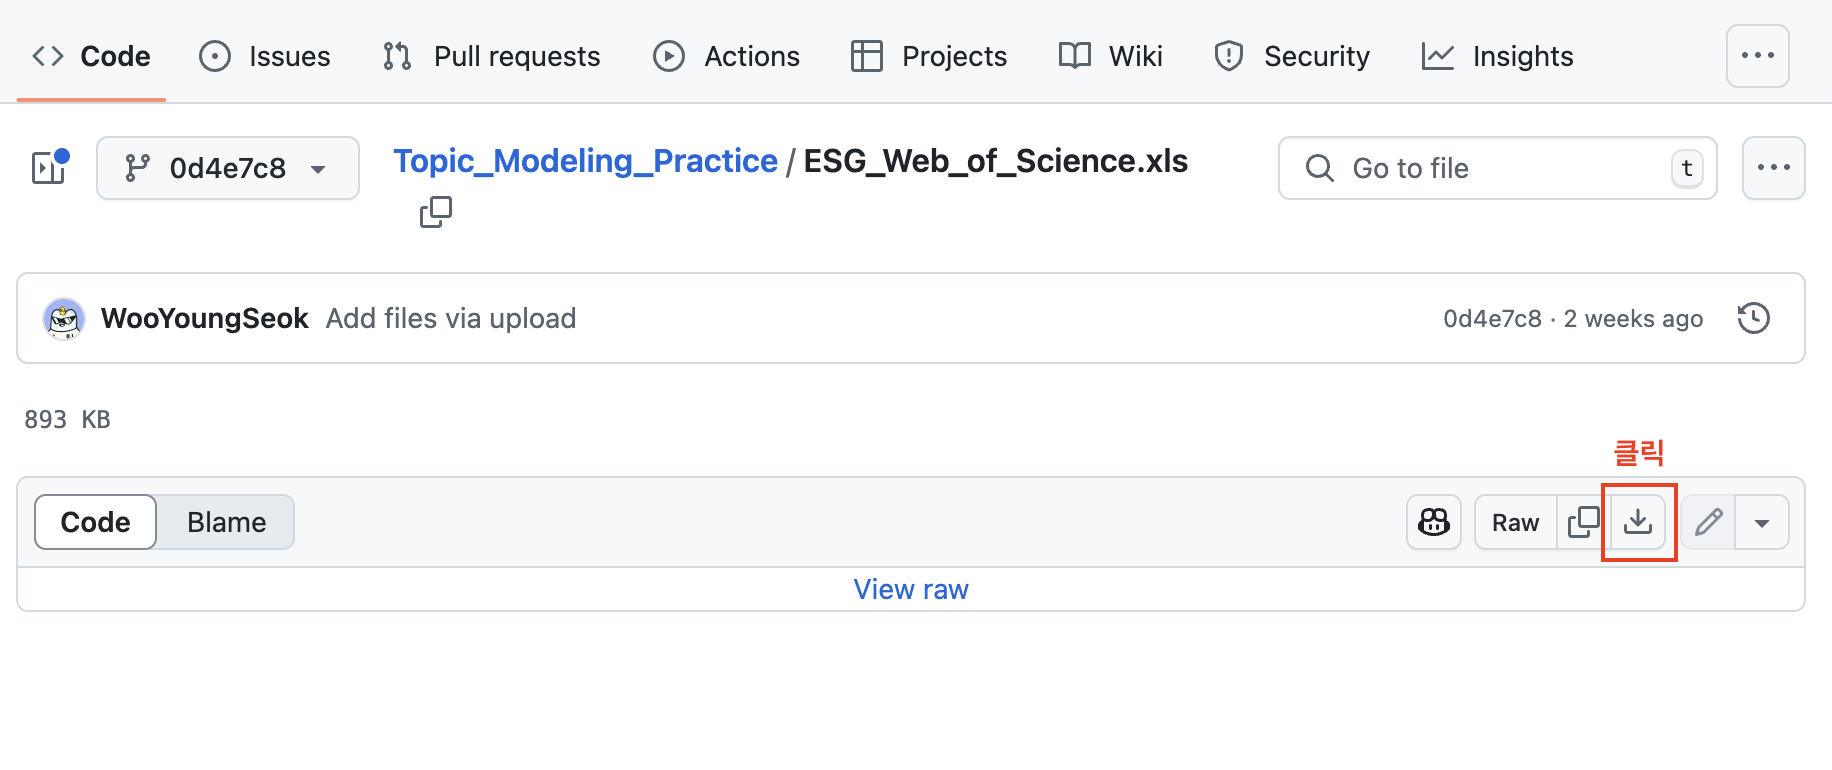
'download the raw file' 클릭



In [2]:
import pandas as pd

data = pd.read_excel('/content/LLM_WfS_0717.xls')
print('논문 개수 :',len(data))

논문 개수 : 1000


In [3]:
# 데이터 확인
data.head(5)

,Publication Type,Authors,Book Authors,Book Editors,Book Group Authors,Author Full Names,Book Author Full Names,Group Authors,Article Title,Source Title,...,Web of Science Index,Research Areas,IDS Number,Pubmed Id,Open Access Designations,Highly Cited Status,Hot Paper Status,Date of Export,UT (Unique WOS ID),Web of Science Record
0,J,"Zhao, YJ; Hou, XY; Wang, SA; Wang, HY",NaN,NaN,NaN,"Zhao, Yanjie; Hou, Xinyi; Wang, Shenao; Wang, ...",NaN,NaN,LLM App Store Analysis: A Vision and Roadmap,ACM TRANSACTIONS ON SOFTWARE ENGINEERING AND M...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:001505551000027,0
1,C,"Wu, MQ; Kang, YX; Li, XC; Hu, SY; Chen, XT; Ka...",NaN,"Lin, Z; Cheng, MM; He, R; Ubul, K; Silamu, W; ...",NaN,"Wu, Meiqi; Kang, Yaxuan; Li, Xuchen; Hu, Shiyu...",NaN,NaN,VS-LLM: Visual-Semantic Depression Assessment ...,"PATTERN RECOGNITION AND COMPUTER VISION, PT IX...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:001413310600017,0
2,J,"Zhang, L; Hu, YX; Li, WH; Bai, Q; Nand, P",NaN,NaN,NaN,"Zhang, Lan; Hu, Yuxuan; Li, Weihua; Bai, Quan;...",NaN,NaN,LLM-AIDSim: LLM-Enhanced Agent-Based Influence...,SYSTEMS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:001405152200001,0
3,C,"Köpke, J; Safan, A",NaN,"Gdowska, K; Gomez-Lopez, MT; Rehse, JR",NaN,"Koepke, Julius; Safan, Aya",NaN,NaN,Efficient LLM-Based Conversational Process Mod...,"BUSINESS PROCESS MANAGEMENT WORKSHOPS, BPM 2024",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:001467337000020,0
4,C,"Szymanski, A; Ziems, N; Eicher-Miller, HA; Li,...",NaN,NaN,ACM,"Szymanski, Annalisa; Ziems, Noah; Eicher-Mille...",NaN,NaN,Limitations of the LLM-as-a-Judge Approach for...,PROCEEDINGS OF THE 2025 CONFERENCE ON INTELLIG...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:001477132000056,0


In [4]:
# 열 이름 출력
data.columns

Index(['Publication Type', 'Authors', 'Book Authors', 'Book Editors',
       'Book Group Authors', 'Author Full Names', 'Book Author Full Names',
       'Group Authors', 'Article Title', 'Source Title', 'Book Series Title',
       'Book Series Subtitle', 'Language', 'Document Type', 'Conference Title',
       'Conference Date', 'Conference Location', 'Conference Sponsor',
       'Conference Host', 'Author Keywords', 'Keywords Plus', 'Abstract',
       'Addresses', 'Affiliations', 'Reprint Addresses', 'Email Addresses',
       'Researcher Ids', 'ORCIDs', 'Funding Orgs', 'Funding Name Preferred',
       'Funding Text', 'Cited References', 'Cited Reference Count',
       'Times Cited, WoS Core', 'Times Cited, All Databases',
       '180 Day Usage Count', 'Since 2013 Usage Count', 'Publisher',
       'Publisher City', 'Publisher Address', 'ISSN', 'eISSN', 'ISBN',
       'Journal Abbreviation', 'Journal ISO Abbreviation', 'Publication Date',
       'Publication Year', 'Volume', 'Issue', 'Pa

In [5]:
# 'Abstract' 열만 선택하여 새로운 DataFrame에 저장
# 이는 논문의 주제를 요약하기 위해 Abstract 내용만 사용하기 위함입니다.
abstract = data[['Abstract']]
abstract.head(5)

,Abstract
0,The rapid growth and popularity of large langu...
1,The Drawing Projection Test (DPT) is an essent...
2,This paper introduces an LLM-Enhanced Agent-Ba...
3,"Since the introduction of OpenAI's ChatGPT, th..."
4,The potential of using Large Language Models (...


In [6]:
# 'Abstract' 컬럼의 결측값(NaN)을 제거합니다
abstract = abstract.dropna(subset=['Abstract'])

print('결측값 제거 후 논문 개수 :',len(abstract))

결측값 제거 후 논문 개수 : 966


In [7]:
print('기존 총 문서의 수 :', len(data))

기존 총 문서의 수 : 1000


## 2. 토픽 모델링

토픽 모델링 수행 방법
*  BERTopic의 모델 객체를 만들고,
*  fit_transform 메소드에 문자열들의 리스트를 입력으로 넣기

In [8]:
# 2분 소요
from bertopic import BERTopic

In [9]:
model = BERTopic() # 간단한 실습을 위해 기본 옵션 사용
topics, probabilities = model.fit_transform(abstract['Abstract'])
# 3분 정도 소요

print('각 문서의 토픽 번호 리스트 :',len(topics))
print('첫번째 문서의 토픽 번호 :', topics[0])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

각 문서의 토픽 번호 리스트 : 966
첫번째 문서의 토픽 번호 : 13


### 🔄 **BERTopic 모델 저장 및 재사용 안내**

* 모델 저장해야 하는 이유

1. BERTopic을 활용한 토픽 모델링은 데이터셋에 따라 모델 학습에 상당한 시간이 소요될 수 있음

2. 모델을 새로 학습하면, 동일한 데이터셋에 대해서도 토픽

⚠️ 단, 모델을 재사용하려면 학습에 사용한 환경(라이브러리 버전 등)이 동일해야 하므로 주의가 필요합니다.

특히 Google Colab에서는 시간이 지나면 자동으로 패키지 버전이 업데이트되는 경우가 많으므로,

장기간 사용하지 않았다면 모델을 불러오기 전에 버전을 확인하거나, 필요 시 재설치해야 합니다.

In [10]:
model.save("my_topics_model")

# 모델 load 시, 아래 코드 주석 해제
# BerTopic_model = BERTopic.load("my_topics_model")

2025-07-17 08:32:52,523 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [11]:
model.get_topic_info()
# 토픽의 개수, 토픽의 크기, 각 토픽에 할당된 단어들을 일부 확인 가능

,Topic,Count,Name,Representation,Representative_Docs
0,-1,249,-1_the_and_of_to,"[the, and, of, to, in, for, this, llms, we, with]",[The rapid development of large language model...
1,0,134,0_and_the_of_in,"[and, the, of, in, to, for, were, medical, cli...",[Large language models (LLMs) and natural lang...
2,1,93,1_the_and_to_in,"[the, and, to, in, of, we, for, with, models, ...","[In object goal navigation tasks, the robot's ..."
3,2,84,2_the_of_and_to,"[the, of, and, to, in, security, for, llms, we...",[The detection of security vulnerabilities in ...
4,3,51,3_sentiment_the_of_and,"[sentiment, the, of, and, to, in, text, detect...",[This paper scrutinizes the unintended consequ...
5,4,49,4_students_the_of_and,"[students, the, of, and, to, feedback, in, lea...",[System architecture design is a crucial skill...
6,5,49,5_inference_memory_to_the,"[inference, memory, to, the, and, of, gpu, llm...",[This study investigates the performance of se...
7,6,46,6_the_knowledge_and_of,"[the, knowledge, and, of, to, in, for, data, f...",[Effective decision-making during earthquake e...
8,7,33,7_the_agents_and_of,"[the, agents, and, of, to, in, for, agent, thi...",[Introduction The surge in the capabilities of...
9,8,25,8_of_ai_the_social,"[of, ai, the, social, and, to, in, chatbots, t...",[Large Language Models (LLMs) enable natural l...



> `Topic -1`의 의미




* `Topic -1`은 **HDBSCAN이 어떤 클러스터에도 포함되지 않는다고 판단한 문서들**
* 이는 모델이 특정 토픽에 할당하지 못한 \*\*이상치(outliers)\*\*로 간주된 문서
* `Topic -1`에 문서가 너무 많으면, 임베딩이나 클러스터링 단계의 하이퍼파라미터 조정이 필요


In [12]:
model.get_topic(0)

[('and', np.float64(0.033720245954259015)),
 ('the', np.float64(0.03306101561756076)),
 ('of', np.float64(0.03156911350673403)),
 ('in', np.float64(0.026457248084087066)),
 ('to', np.float64(0.024543361536658273)),
 ('for', np.float64(0.02188854339831489)),
 ('were', np.float64(0.02063345629564853)),
 ('medical', np.float64(0.02032955982153166)),
 ('clinical', np.float64(0.020184481649713232)),
 ('llm', np.float64(0.020152852993127073))]

In [13]:
# 해당 토픽의 단어 중요도를 잘 보이도록 수정
topic = model.get_topic(0)

cleaned_topic = [(word, float(score)) for word, score in topic]
cleaned_topic

[('and', 0.033720245954259015),
 ('the', 0.03306101561756076),
 ('of', 0.03156911350673403),
 ('in', 0.026457248084087066),
 ('to', 0.024543361536658273),
 ('for', 0.02188854339831489),
 ('were', 0.02063345629564853),
 ('medical', 0.02032955982153166),
 ('clinical', 0.020184481649713232),
 ('llm', 0.020152852993127073)]

## 3. 토픽 시각화

시각화를 통해 생성된 토픽에 대해 더 많은 통찰력을 얻을 수 있음

In [ ]:
# 토픽 간 거리 그래프
# -1 토픽을 제외하고 유의미한 토픽이 2개라면, 시각화 안됨
model.visualize_topics()

In [ ]:
# 토픽 간 유사도 시각화
model.visualize_heatmap()

## 🔢 4. 토픽 수 조정
토픽 모델링을 수행할 때, 생성된 토픽 수가 너무 많거나 너무 적을 수 있습니다.

BERTopic에서는 이러한 경우 토픽 수를 직접 조정할 수 있는 기능을 제공합니다.

✅ 방법 1: 모델 생성 시 nr_topics 지정

모델을 처음 생성할 때 원하는 토픽 수를 nr_topics 인자로 지정하면,

 BERTopic이 유사한 토픽들을 병합하여 해당 개수만큼의 토픽으로 줄여줍니다.

In [ ]:
model = BERTopic(nr_topics=10)
topics, probabilities = model.fit_transform(abstract['Abstract'])
# 3분 정도 소요

model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,234,-1_the_and_of_to,"[the, and, of, to, in, for, llms, this, we, with]",[Recent advancements in large language models ...
1,0,216,0_the_and_of_to,"[the, and, of, to, in, for, with, llms, llm, m...",[Background: The rapid advancements in natural...
2,1,180,1_the_and_to_of,"[the, and, to, of, in, for, we, with, llm, on]",[The rise of Large Language Models (LLMs) has ...
3,2,94,2_the_and_of_to,"[the, and, of, to, in, for, knowledge, data, t...",[Industry 5.0 highlights the human-machine col...
4,3,79,3_the_and_of_to,"[the, and, of, to, in, security, for, we, by, ...",[Unit testing aims to validate the correctness...
5,4,61,4_students_the_of_and,"[students, the, of, and, to, in, for, feedback...",[System architecture design is a crucial skill...
6,5,36,5_the_recommendation_to_and,"[the, recommendation, to, and, user, of, in, w...",[With the rapid development of online services...
7,6,32,6_and_of_the_in,"[and, of, the, in, to, with, users, that, soci...",[Large Language Models (LLMs) have shown impre...
8,7,17,7_privacy_and_data_the,"[privacy, and, data, the, of, llms, to, llm, f...",[The rise of end-user applications powered by ...
9,8,17,8_the_materials_and_crystal,"[the, materials, and, crystal, properties, of,...","[In this work, we show that employing retrieva..."


In [ ]:
# 토픽 간 거리 그래프
# -1 토픽을 제외하고 유의미한 토픽이 2개라면, 시각화 안됨
model.visualize_topics()

✅ 방법 2: 모델 생성 시 nr_topics를 auto로 지정

BERTopic이 자동으로 토픽의 수를 줄이도록 설정하는 것

In [ ]:
# 3분 정도 소요
model = BERTopic(nr_topics="auto")
topics, probabilities = model.fit_transform(abstract['Abstract'])

model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,200,-1_the_and_to_of,"[the, and, to, of, in, for, llms, this, we, with]",[Large Language Models (LLMs) have found exten...
1,0,676,0_the_and_of_to,"[the, and, of, to, in, for, with, this, llms, we]","[Breast cancer (BrCa), being one of the most p..."
2,1,41,1_the_of_and_in,"[the, of, and, in, to, that, with, design, soc...",[This article examines the linguistic framing ...
3,2,19,2_the_and_of_materials,"[the, and, of, materials, to, crystal, propert...","[In this work, we show that employing retrieva..."
4,3,18,3_privacy_and_the_data,"[privacy, and, the, data, of, to, llms, for, i...",[Individuals and businesses have been signific...
5,4,12,4_and_virtual_the_in,"[and, virtual, the, in, to, of, social, user, ...","[We present Explainable XR, an end-to-end fram..."


In [ ]:
# 토픽 간 거리 그래프
# -1 토픽을 제외하고 유의미한 토픽이 2개라면, 시각화 안됨
model.visualize_topics()

## 🔍 5. 임의의 문서에 대한 토픽 예측
학습이 완료된 BERTopic 모델을 사용하면,

새로운 문서가 어떤 토픽에 속하는지 예측할 수 있습니다.


In [ ]:
new_doc = abstract['Abstract'][0]
print(new_doc)

The rapid growth and popularity of large language model (LLM) app stores have created new opportunities and challenges for researchers, developers, users, and app store managers. As the LLM app ecosystem continues to evolve, it is crucial to understand the current landscape and identify potential areas for future research and development. This article presents a forward-looking analysis of LLM app stores, focusing on key aspects such as data mining, security risk identification, development assistance, and market dynamics. Our comprehensive examination extends to the intricate relationships between various stakeholders and the technological advancements driving the ecosystem's growth. We explore the ethical considerations and potential societal impacts of widespread LLM app adoption, highlighting the need for responsible innovation and governance frameworks. By examining these aspects, we aim to provide a vision for future research directions and highlight the importance of collaborati

In [ ]:
topics, probs = model.transform([new_doc])
print('예측한 토픽 번호 :', topics)
print("토픽별 확률 분포:", probs) # 약 30%

예측한 토픽 번호 : [np.int64(3)]
토픽별 확률 분포: [0.33008172]
